# P1.2 experiment history

A compact overview of the earlier continual-adaptation experiments. Run all cells from the repository root or from this `notebooks/` directory. The notebook reads the existing ignored `outputs/` artifacts; it does not need BDD100K itself.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def find_repo_root(start: Path) -> Path:
    """Locate the repository from the current working directory."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "cafl4ds").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the cafl4ds repository.")


REPO = find_repo_root(Path.cwd().resolve())

EXPERIMENTS = [
    ("STL-10 first run", "outputs/adaptation/20260917-143304/comparison.json"),
    ("BDD initial run", "outputs/adaptation-bdd/20260917-185749/comparison.json"),
    ("BDD fixed replay", "outputs/adaptation-bdd/replay-sweeps/20260918-135628/reservoir_compute/comparison.json"),
    ("Full BDD MAE, random init", "outputs/adaptation-bdd/full-mae/20260921-full-pilot-s11/comparison.json"),
    ("Clean warm pilot", "outputs/adaptation-bdd/clean-warm-mae/20260921-pilot-s101/full/comparison.json"),
    ("Clean warm replay pilot", "outputs/adaptation-bdd/clean-warm-mae-replay/20260921-s101/comparison.json"),
    ("Clean warm confirmation", "outputs/adaptation-bdd/clean-warm-confirmation/20260922/full/comparison.json"),
    ("Replay confirmation", "outputs/adaptation-bdd/clean-warm-confirmation/20260922/replay/comparison.json"),
]

print(f"Repository: {REPO}")

Repository: C:\Users\ehceirs\Documents\ChatGPT\Continuous, Active Federated Learning for Data Streams\cafl4ds


In [3]:
def load_summary(label: str, relative_path: str) -> dict[str, float | int | str]:
    """Read one experiment's aggregate gains and retention measures."""
    path = REPO / relative_path
    report = json.loads(path.read_text(encoding="utf-8"))
    aggregate = report["aggregate"]
    seeds = report["seeds"]
    bwt = [seed["conditions"]["adapted_summary"]["backward_transfer"] for seed in seeds]
    forgetting = [seed["conditions"]["adapted_summary"]["forgetting_measure"] for seed in seeds]
    return {
        "Experiment": label,
        "Seeds": int(aggregate["n_seeds"]),
        "kNN gain (pp)": 100 * aggregate["global"]["knn"]["mean_gain"],
        "Linear gain (pp)": 100 * aggregate["global"]["linear"]["mean_gain"],
        "Final-condition gain (pp)": 100 * aggregate["final_condition_gain"]["mean_gain"],
        "BWT (pp)": 100 * sum(bwt) / len(bwt),
        "Forgetting (pp)": 100 * sum(forgetting) / len(forgetting),
        "Path": relative_path,
    }


rows = []
missing = []
for label, relative_path in EXPERIMENTS:
    if (REPO / relative_path).is_file():
        rows.append(load_summary(label, relative_path))
    else:
        missing.append(relative_path)

if missing:
    print("Skipped missing local artifacts:")
    for path in missing:
        print(f"  - {path}")
if not rows:
    raise FileNotFoundError("No comparison.json files were found under outputs/.")

summary = pd.DataFrame(rows).set_index("Experiment")
summary.drop(columns="Path").style.format(precision=2)

,Seeds,kNN gain (pp),Linear gain (pp),Final-condition gain (pp),BWT (pp),Forgetting (pp)
Experiment,,,,,,
STL-10 first run,3,-4.17,-5.56,-3.13,-2.78,3.24
BDD initial run,5,3.20,2.93,0.01,-0.57,4.70
BDD fixed replay,5,-1.07,5.07,0.08,0.32,3.81
"Full BDD MAE, random init",1,-4.00,-8.00,-1.90,-5.82,13.69
Clean warm pilot,1,10.67,9.33,1.36,-4.67,12.61
Clean warm replay pilot,1,8.00,0.00,5.50,1.73,4.22
Clean warm confirmation,3,4.00,-6.22,1.68,3.46,11.40
Replay confirmation,3,11.11,-1.33,3.46,-0.03,6.74


## Accuracy relative to the frozen twin

Positive values mean that the continually adapted encoder beat its initialization-matched frozen control.

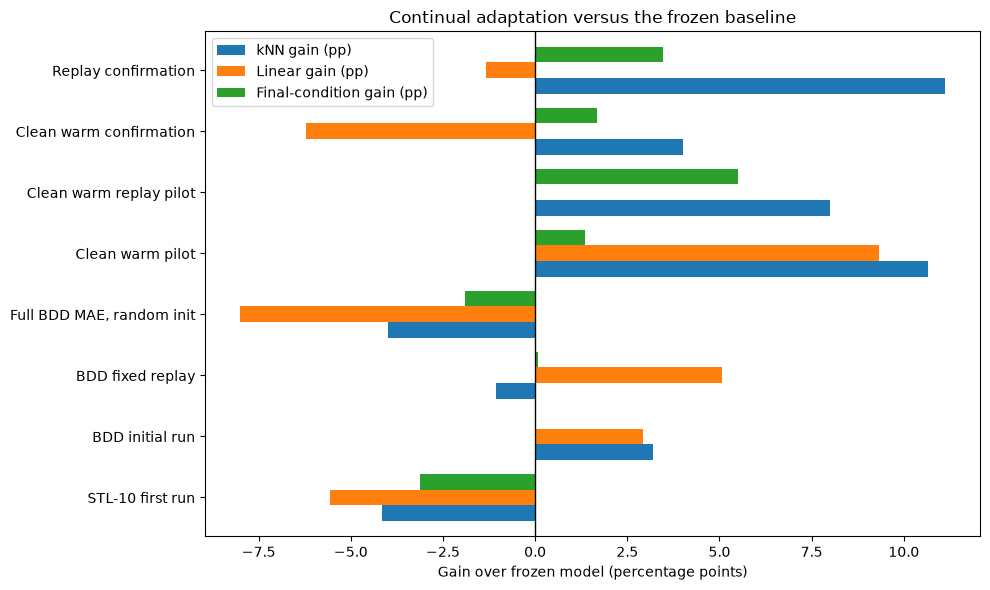

In [4]:
gain_columns = ["kNN gain (pp)", "Linear gain (pp)", "Final-condition gain (pp)"]
ax = summary[gain_columns].plot.barh(figsize=(10, 6), width=0.78)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Gain over frozen model (percentage points)")
ax.set_ylabel("")
ax.set_title("Continual adaptation versus the frozen baseline")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## Retention

Lower forgetting is better. Positive backward transfer (BWT) means later learning improved earlier conditions on average.

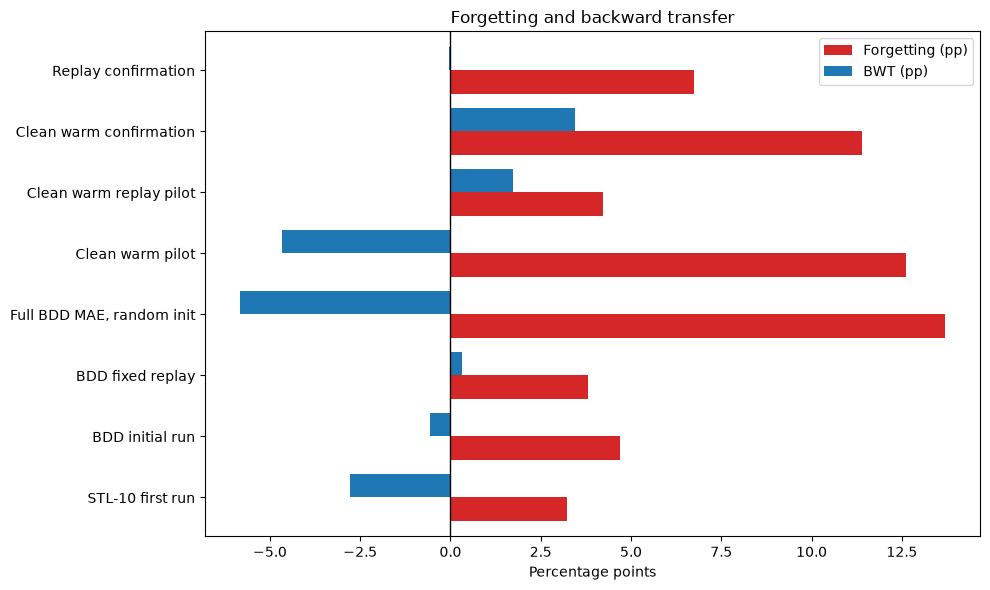

In [5]:
retention = summary[["Forgetting (pp)", "BWT (pp)"]]
ax = retention.plot.barh(figsize=(10, 6), width=0.78, color=["tab:red", "tab:blue"])
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Percentage points")
ax.set_ylabel("")
ax.set_title("Forgetting and backward transfer")
plt.tight_layout()
plt.show()

## Final three-seed confirmation

This table exposes the individual seeds behind the final averages.

In [6]:
confirmation_rows = []
for arm, relative_path in [
    ("No replay", "outputs/adaptation-bdd/clean-warm-confirmation/20260922/full/comparison.json"),
    ("Replay", "outputs/adaptation-bdd/clean-warm-confirmation/20260922/replay/comparison.json"),
]:
    path = REPO / relative_path
    if not path.is_file():
        continue
    report = json.loads(path.read_text(encoding="utf-8"))
    for seed in report["seeds"]:
        retention = seed["conditions"]["adapted_summary"]
        confirmation_rows.append(
            {
                "Arm": arm,
                "Seed": seed["seed"],
                "kNN gain (pp)": 100 * seed["global"]["knn"]["gain"],
                "Linear gain (pp)": 100 * seed["global"]["linear"]["gain"],
                "BWT (pp)": 100 * retention["backward_transfer"],
                "Forgetting (pp)": 100 * retention["forgetting_measure"],
            }
        )

confirmation = pd.DataFrame(confirmation_rows)
confirmation.style.format(precision=2)

,Arm,Seed,kNN gain (pp),Linear gain (pp),BWT (pp),Forgetting (pp)
0,No replay,103,6.67,2.67,2.41,9.92
1,No replay,107,2.67,-10.67,2.44,14.12
2,No replay,109,2.67,-10.67,5.54,10.16
3,Replay,103,16.00,-4.00,2.29,3.98
4,Replay,107,8.00,1.33,-7.16,11.86
5,Replay,109,9.33,-1.33,4.77,4.37


## How to read the history

The early random-initialization and ordinary online-learning runs did not reliably beat their frozen twins. A clean train-only MAE warm start made useful adaptation possible. Compute-matched replay then improved kNN gain and reduced forgetting, but the linear-probe gain remained inconsistent.